In [1]:
from utils.dependencies import *;

/home/bepennell/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import ComputeMultiplicity as cm

# Generate Synthetic Data

In [4]:
asp_import("synthetic_ms_candidates", "sd")

<module 'synthetic_ms_candidates' from '/home/bepennell/research/AstrometricSignalProcessing/SyntheticDatasets/synthetic_ms_candidates.py'>

In [5]:
mdwarfs = Table.read('./data/2026_06_09_final_table.fits', format='fits')
reduced_mdwarfs = mdwarfs[["ra", "dec", "pmra", "pmdec", "parallax", "phot_g_mean_mag", "bp_rp", "mass", "mass_single", "mh_single", "q_max"]]
res = sd.create_synthetic_data(object_count=50000, catalogue=reduced_mdwarfs, binary_fraction=100, period_model=(4,1.3), mass_model=0, ecc_type="turnover", return_ruwe=True, return_fits=False)

Computing Singles: 0it [00:00, ?it/s]

Computing Binaries:   0%|          | 0/50000 [00:00<?, ?it/s]

In [6]:
orbit_solutions = Table.read("./data/2026_06_09_orbit_solutions.fits", format="fits")

In [7]:
hist_setups = {
    "lw": 5,
    "baseline": None
}
parent_setup = {
    "lw": 5,
    "baseline": None,
    "color": "firebrick", 
    "zorder": 0, 
    "alpha": 0.4
}

In [9]:
synth_bins = res[res["is_binary"] == True]
periods = np.array([np.log10(s["period"]) for s in synth_bins]) 
in_period_mask = (periods >= 1.75) & (periods <= 3.5)
synth_bins = synth_bins[in_period_mask]
synth_nss = res[res["solution_type"] == 12]

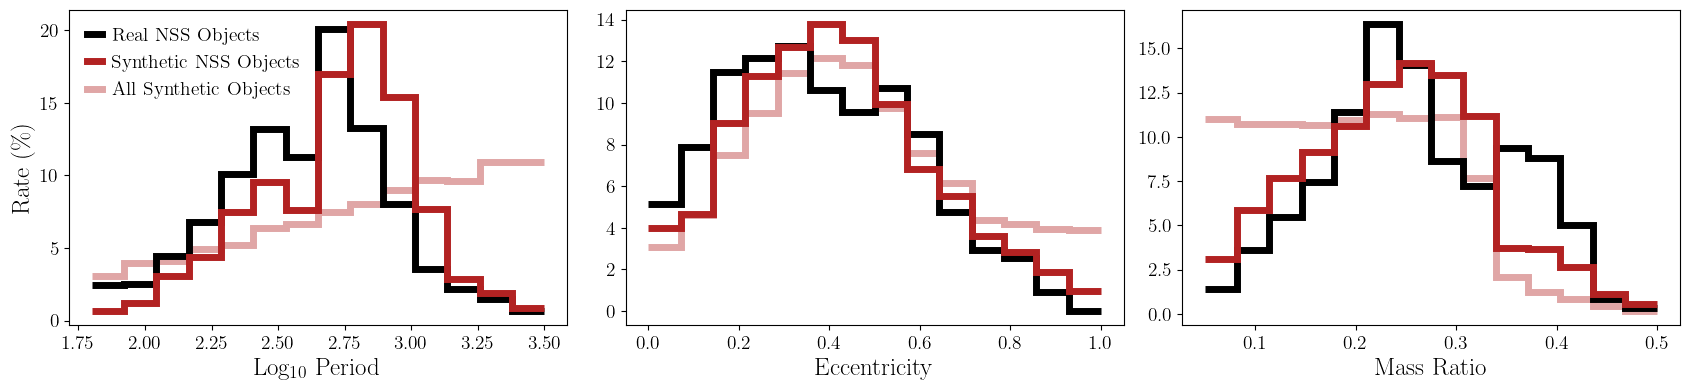

In [10]:
fig, axs = plt.subplots(1,3, figsize=(17,4))

### PERIOD ###
ax = axs[0]
period_bins = np.linspace(1.8,3.5,15)

vals, bins = np.histogram(np.log10(orbit_solutions["period"]), bins=period_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **hist_setups, label="Real NSS Objects")

vals, bins = np.histogram([np.log10(s["period"]) for s in synth_nss], bins=period_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **hist_setups, label="Synthetic NSS Objects")

vals, bins = np.histogram([np.log10(s["period"]) for s in synth_bins], bins=period_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **parent_setup, label="All Synthetic Objects")

ax.set_xlabel(r"Log$_{10}$ Period");
ax.set_ylabel("Rate (\%)");
ax.legend(handletextpad=0.5);

### ECCENTRICITY ###
ax = axs[1]
eccentricity_bins = np.linspace(0,1,15)

vals, bins = np.histogram(orbit_solutions["eccentricity"], bins=eccentricity_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **hist_setups, label="Real NSS Objects")

vals, bins = np.histogram([s["ecc"] for s in synth_nss], bins=eccentricity_bins)
ecc_nss_vals = vals/np.sum(vals)*100
ax.stairs(ecc_nss_vals, bins, **hist_setups, label="Synthetic NSS Objects")

vals, bins = np.histogram([s["ecc"] for s in synth_bins], bins=eccentricity_bins)
ecc_all_vals = vals/np.sum(vals)*100
ax.stairs(ecc_all_vals, bins, **parent_setup, label="All Synthetic Objects")

ax.set_xlabel("Eccentricity");

### MASS RATIO ###
ax = axs[2]
q_bins = np.linspace(0.05,0.5,15)

#vals, bins = np.histogram(orbit_solutions["m2_binary"]/orbit_solutions["m1_binary"], bins=q_bins)
vals, bins = np.histogram(orbit_solutions["m2"]/orbit_solutions["mass_single"], bins=q_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **hist_setups, label="Real NSS Objects")

vals, bins = np.histogram([s["m2"]/s["mass"] for s in synth_nss], bins=q_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **hist_setups, label="Synthetic NSS Objects")

vals, bins = np.histogram([s["m2"]/s["mass"] for s in synth_bins], bins=q_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **parent_setup, label="All Synthetic Objects")

ax.set_xlabel(r"Mass Ratio");

plt.tight_layout()
plt.savefig("./plots/selection_function_correction.pdf", transparent=True, dpi=800)

# Variable Binarity

In [ ]:
REF_FRACTIONS = (0.25, 0.5)
MASS_RANGE = (0.2, 0.75)
def bin_frac(m):
    sep = (m - MASS_RANGE[0]) / (MASS_RANGE[1] - MASS_RANGE[0])
    return sep * (REF_FRACTIONS[1] - REF_FRACTIONS[0]) + REF_FRACTIONS[0]

In [4]:
mdwarfs = Table.read('./data/2026_06_09_final_table.fits', format='fits')
reduced_mdwarfs = mdwarfs[["ra", "dec", "pmra", "pmdec", "parallax", "phot_g_mean_mag", "bp_rp", "mass", "mass_single", "mh_single", "q_max"]]

In [5]:
res = sd.create_synthetic_data(object_count=250000, catalogue=reduced_mdwarfs, binarity_model=bin_frac, period_model=(4,1.3), mass_model=0, ecc_type="turnover", return_ruwe=True, return_fits=False)

Computing Singles:   0%|          | 0/159962 [00:00<?, ?it/s]

Computing Binaries:   0%|          | 0/90038 [00:00<?, ?it/s]

In [6]:
res.write("./data/2026-06-12-synthetic_data.fits", format="fits", overwrite=True)

# Compare NSS objects to Fiducial Models

In [7]:
synthdata = Table.read("./data/2026-06-12-synthetic_data.fits", format="fits")
synth_bins = synthdata[synthdata["is_binary"] == True]
periods = np.array([np.log10(s["period"]) for s in synth_bins]) 
in_period_mask = (periods >= 1.75) & (periods <= 3.5)
synth_bins = synth_bins[in_period_mask]
synth_nss = synthdata[synthdata["solution_type"] == 12]

In [8]:
orbit_solutions = Table.read("./data/2026_06_09_orbit_solutions.fits", format="fits")

In [9]:
hist_setups = {
    "lw": 5,
    "baseline": None
}
parent_setup = {
    "lw": 5,
    "baseline": None,
    "color": "firebrick", 
    "zorder": 0, 
    "alpha": 0.4
}

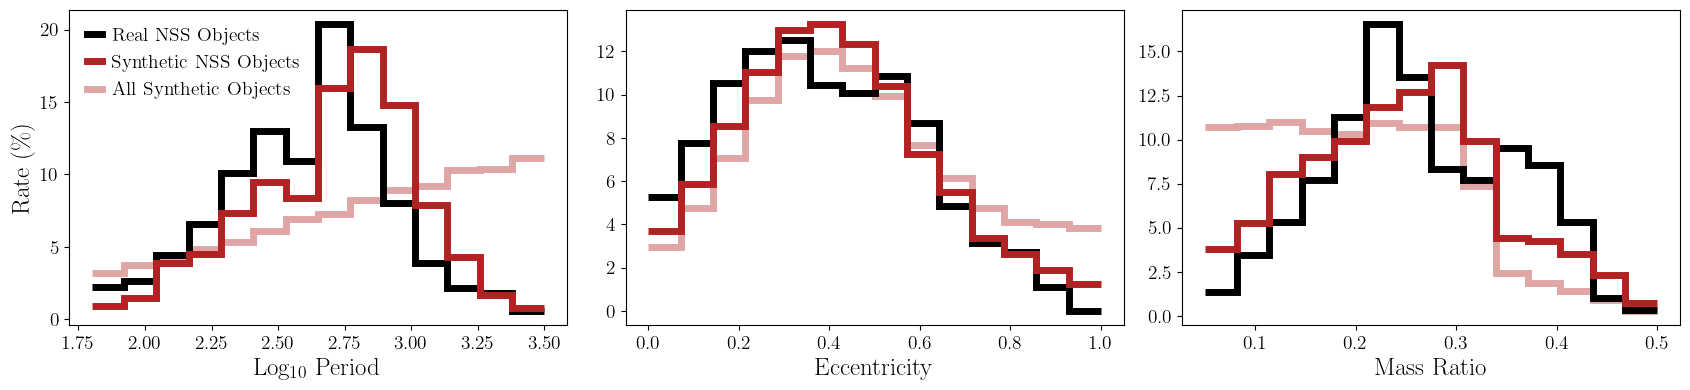

In [12]:
fig, axs = plt.subplots(1,3, figsize=(17,4))

### PERIOD ###
ax = axs[0]
period_bins = np.linspace(1.8,3.5,15)

vals, bins = np.histogram(np.log10(orbit_solutions["period"]), bins=period_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **hist_setups, label="Real NSS Objects")

vals, bins = np.histogram([np.log10(s["period"]) for s in synth_nss], bins=period_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **hist_setups, label="Synthetic NSS Objects")

vals, bins = np.histogram([np.log10(s["period"]) for s in synth_bins], bins=period_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **parent_setup, label="All Synthetic Objects")

ax.set_xlabel(r"Log$_{10}$ Period");
ax.set_ylabel("Rate (\%)");
ax.legend(handletextpad=0.5);

### ECCENTRICITY ###
ax = axs[1]
eccentricity_bins = np.linspace(0,1,15)

vals, bins = np.histogram(orbit_solutions["eccentricity"], bins=eccentricity_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **hist_setups, label="Real NSS Objects")

vals, bins = np.histogram([s["ecc"] for s in synth_nss], bins=eccentricity_bins)
ecc_nss_vals = vals/np.sum(vals)*100
ax.stairs(ecc_nss_vals, bins, **hist_setups, label="Synthetic NSS Objects")

vals, bins = np.histogram([s["ecc"] for s in synth_bins], bins=eccentricity_bins)
ecc_all_vals = vals/np.sum(vals)*100
ax.stairs(ecc_all_vals, bins, **parent_setup, label="All Synthetic Objects")

ax.set_xlabel("Eccentricity");

### MASS RATIO ###
ax = axs[2]
q_bins = np.linspace(0.05,0.5,15)

#vals, bins = np.histogram(orbit_solutions["m2_binary"]/orbit_solutions["m1_binary"], bins=q_bins)
vals, bins = np.histogram(orbit_solutions["m2"]/orbit_solutions["mass_single"], bins=q_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **hist_setups, label="Real NSS Objects")

vals, bins = np.histogram([s["m2"]/s["mass"] for s in synth_nss], bins=q_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **hist_setups, label="Synthetic NSS Objects")

vals, bins = np.histogram([s["m2"]/s["mass"] for s in synth_bins], bins=q_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **parent_setup, label="All Synthetic Objects")

ax.set_xlabel(r"Mass Ratio");

plt.tight_layout()
plt.savefig("./plots/selection_function_correction.pdf", transparent=True, dpi=800)

# Constrain Multiplicity Fractions

In [3]:
synthdata = Table.read("./data/2026-06-12-synthetic_data.fits", format="fits")
sc_cube = pickle.load(open("./data/2026-06-14-mag_scaled.pkl", "rb"))

In [11]:
likelihoods = []
masses = synthdata["mass"]
bins = 10
model_cube = cm.create_model_cube(grid_shape=(50,35), p_model=(4,1.3), q_model=0)
percs = np.percentile(masses, np.linspace(0,100,bins+1))
for i in range(bins):
    subset = synthdata[(synthdata["mass"] >= percs[i]) & (synthdata["mass"] < percs[i+1])]
    reduced_memory = subset[["solution_type", "phot_g_mean_mag", "parallax", "mass", "q_max", "is_binary"]]
    fbs, likelihoods_bin = cm.multiplicity(catalogue=reduced_memory, model_cube=model_cube, sc_cube=sc_cube, resolution=1000, cutoff=np.exp(-30), scale=5, verbose=True, combine_higher_order=True)
    likelihoods.append(likelihoods_bin)
    print(fbs[np.argmax(likelihoods_bin)])

Computing grids:   0%|          | 0/25000 [00:00<?, ?it/s]

Computing likelihoods:   0%|          | 0/1000 [00:00<?, ?it/s]

0.28522522522522525


Computing grids:   0%|          | 0/25000 [00:00<?, ?it/s]

Computing likelihoods:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Computing likelihoods:   0%|          | 0/1000 [00:00<?, ?it/s]

0.47741741741741744


Computing grids:   0%|          | 0/24998 [00:00<?, ?it/s]

Computing likelihoods:   0%|          | 0/1000 [00:00<?, ?it/s]

0.5273873873873874


In [ ]:
orbit_solutions = Table.read("./data/2026_05_19_orbit_solutions.fits", format="fits")

In [ ]:
hist_setups = {
    "lw": 5,
    "baseline": None
}
parent_setup = {
    "lw": 5,
    "baseline": None,
    "color": "firebrick", 
    "zorder": 0, 
    "alpha": 0.4
}

In [13]:
def uncertainty(likelihoods, cut=2):
    fbs = np.linspace(0.02, 0.98, len(likelihoods))
    relative_likelihoods = likelihoods - np.max(likelihoods)

    peakdx = np.argmax(likelihoods)
    max_fb = fbs[peakdx]    
    sigma = max_fb - fbs[:peakdx][np.argmin(abs(relative_likelihoods[:peakdx]+cut))]
    return max_fb, sigma

In [11]:
likelihoods = pickle.load(open("./plot_data/2026-06-14-synth_inference.pkl", "rb"))["likelihoods"]

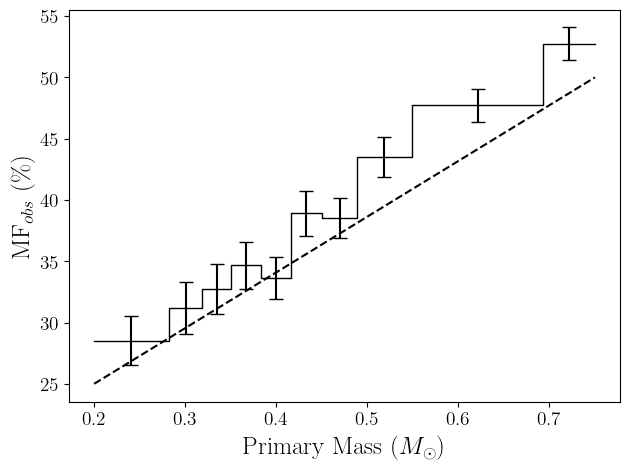

In [16]:
masses = synthdata["mass"]
bins = 10
percs = np.percentile(masses, np.linspace(0,100,bins+1))
mass_lims_b = np.clip(percs, None, 0.75)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
synth_results = np.array([uncertainty(l) for l in likelihoods])

plt.errorbar(bin_centers, synth_results[:,0]*100, yerr=(synth_results[:,1]*100), fmt='none', capsize=5, ecolor='k', zorder=1)
plt.plot(mass_lims_b.repeat(2)[1:-1], (100*synth_results[:,0]).repeat(2), c="k", lw=1, zorder=1);
plt.xlabel(r"Primary Mass $(M_\odot)$");
plt.ylabel(r"MF$_{obs}$ (\%)");

ms = np.linspace(0.2,0.75,100)  
REF_FRACTIONS = (0.25, 0.5)
MASS_RANGE = (0.2, 0.75)
def bin_frac(m):
    sep = (m - MASS_RANGE[0]) / (MASS_RANGE[1] - MASS_RANGE[0])
    return sep * (REF_FRACTIONS[1] - REF_FRACTIONS[0]) + REF_FRACTIONS[0]
plt.plot(ms, bin_frac(ms)*100, c="k", linestyle="--", zorder=0);

plt.tight_layout();
plt.savefig("./plots/SyntheticInference.pdf", dpi=800, transparent=True)

In [15]:
output = {
    "likelihoods": likelihoods,
}

pickle.dump(output, open("./plot_data/2026-06-14-synth_inference.pkl", "wb"))

In [13]:
len(synthdata[synthdata["is_binary"]])/len(synthdata)

0.360152

In [11]:
print_table(res)

,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,92.62,3.72,1.04,0.18,2.44
Counts,250000,231558,9290,2594,459,6099
